# Распределение товаров по торговым точкам через муравьиный алгоритм

## Библиотеки

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from time import time

## Эвристики

Влияние продаж

In [2]:
sales_factor = 1

Влияние загруженности

In [3]:
load_factor = 0.8

Сколько итераций считать

In [4]:
iterations_count = 100

Ранняя остановка. Если лучшее решение не менялось на протяжении указанного кол-ва итераций, то останваливаем алгоритм. Значение 0 значит без ранней остановки

In [5]:
early_stopping = 0

Если нынешнее лучшее решение не больше предыдущего хотя бы на эпсилон, то лучшее решение не обновляется

In [6]:
epsilon = 0

Константа выделения феромонов. Должна быть очень маленькой, чтобы компенсировать большие значения оценки

In [7]:
pheromone_quantity = 0.000005

Испарение феромонов

In [8]:
pheromone_loss = 0.6

Влияние феромонов

In [9]:
pheromone_factor = 1.2

Влияние эвристик

In [10]:
heuristic_factor = 3

Число муравьёв

In [11]:
ant_count = 10

## Подгрузка датасета

In [12]:
col_vol = "Объём товара в закрывающемся магазине (V)"
col_maxcap = "Максимальная вместимость товара в магазине (M)"
col_item = "Код товара"
col_store = "Магазин"
col_remain = "Остаток товара в магазине (R)"
col_sales = "Продажи товара в магазине (S)"
col_dist = "Распределение муравьёв"

In [13]:
items = pd.read_csv(r"./filtered_datasets/items_closing_store.csv", sep=";")
items = items.set_index([col_item, col_store])
items

Объём товара в закрывающемся магазине (V)  \
Код товара Магазин                                              
226249     54                                            10.0   
           56                                            10.0   
           57                                            10.0   
           60                                            10.0   
           61                                            10.0   
...                                                       ...   
239388     95                                            26.0   
239397     38                                            12.0   
239398     38                                            13.0   
239515     38                                            42.0   
239516     38                                            42.0   

                    Продажи товара в магазине (S)  \
Код товара Магазин                                  
226249     54                            1.379157   
           56                            0.943567   
           57                            0.857143   
           60                            0.406742   
           61                            0.713024   
...                                           ...   
239388     95                            1.500000   
239397     38                            1.116279   
239398     38                            2.023256   
239515     38                            1.796296   
239516     38                            1.740741   

                    Максимальная вместимость товара в магазине (M)  \
Код товара Магазин                                                   
226249     54                                                    8   
           56                                                    8   
           57                                                    8   
           60                                                    8   
           61                                                    8   
...                                                            ...   
239388     95                                                   25   
239397     38                                                   24   
239398     38                                                   24   
239515     38                                                   30   
239516     38                                                   24   

                    Остаток товара в магазине (R)  
Код товара Магазин                                 
226249     54                                16.0  
           56                                22.0  
           57                                19.0  
           60                                28.0  
           61                                22.0  
...                                           ...  
239388     95                                20.0  
239397     38                                21.0  
239398     38                                45.0  
239515     38                                35.0  
239516     38                                28.0  

[413689 rows x 4 columns]

Со всем датасетом работать очень медленно. Гораздо лучше будет сделать несколько матриц

$i$ - товар, $i ∈ [1, N]$, $N$ - кол-во товаров

$j$ - магазин, $j ∈ [1, M]$, $M$ - кол-во магазинов

*closing_volume* - вектор размерности $N×1$, показывает кол-во товара $i$ в закрывающемся магазине

*sales* - матрица размерности $N×M$, показывает продажи товара $i$ в магазине $j$

*maxcap* - матрица размерности $N×M$, показывает вместимость на полках товара $i$ в магазине $j$

*remains* - матрица размерности $N×M$, показывает остатки товара $i$ в магазине $j$

*pheromones* - матрица размерности $N×M$, показывает феромоны для распределения товара $i$ в магазин $j$

Если товар $i$ не числится в магазине $j$, то тогда соответственные значения $(i, j)$ во всех матрицах равны 0

In [14]:
items_id = items.index.get_level_values(0).unique().values
N = items_id.shape[0]

In [15]:
stores_id = items.index.get_level_values(1).unique().values
M = stores_id.shape[0]

In [16]:
print(f"Items: {N}\nStores: {M}")

Items: 5366
Stores: 98


Переиндексация для создания пар $(i, j)$

In [17]:
full_index = pd.MultiIndex.from_product([items_id, stores_id], names=[col_item, col_store])
df_full = items.reindex(full_index)
df_full

Объём товара в закрывающемся магазине (V)  \
Код товара Магазин                                              
226249     54                                            10.0   
           56                                            10.0   
           57                                            10.0   
           60                                            10.0   
           61                                            10.0   
...                                                       ...   
239221     88                                             NaN   
           105                                            NaN   
           29                                             NaN   
           27                                             NaN   
           113                                           17.0   

                    Продажи товара в магазине (S)  \
Код товара Магазин                                  
226249     54                            1.379157   
           56                            0.943567   
           57                            0.857143   
           60                            0.406742   
           61                            0.713024   
...                                           ...   
239221     88                                 NaN   
           105                                NaN   
           29                                 NaN   
           27                                 NaN   
           113                           0.302326   

                    Максимальная вместимость товара в магазине (M)  \
Код товара Магазин                                                   
226249     54                                                  8.0   
           56                                                  8.0   
           57                                                  8.0   
           60                                                  8.0   
           61                                                  8.0   
...                                                            ...   
239221     88                                                  NaN   
           105                                                 NaN   
           29                                                  NaN   
           27                                                  NaN   
           113                                                10.0   

                    Остаток товара в магазине (R)  
Код товара Магазин                                 
226249     54                                16.0  
           56                                22.0  
           57                                19.0  
           60                                28.0  
           61                                22.0  
...                                           ...  
239221     88                                 NaN  
           105                                NaN  
           29                                 NaN  
           27                                 NaN  
           113                                5.0  

[525868 rows x 4 columns]

Превращаем всё теперь в матрицы

In [18]:
closing_volume = items.groupby(level=0, sort=False).first()[col_vol].values
sales = df_full[col_sales].values.reshape(N, M)
maxcap = df_full[col_maxcap].values.reshape(N, M)
remains = df_full[col_remain].values.reshape(N, M)

Заполняем пропуски нулями

In [19]:
sales = np.nan_to_num(sales, nan=0)
maxcap = np.nan_to_num(maxcap, nan=0)
remains = np.nan_to_num(remains, nan=0)

## Муравьиный алгоритм

### Логика движения муравья

Сначала фиксируется товар, потом для него ищется распределение по магазинам, опираясь на случайный выбор по вероятности

In [20]:
def ant_distribution(pheromones):    
    v, s, m, r, w = closing_volume, sales, maxcap, remains, pheromones
    c = np.zeros((N, M), dtype=np.int64)  # изначально распределение равно 0
    
    for i in range(N):        
        item_count = v[i]
        zero_sales = np.max(s[i]) == 0.0  # если у товара везде нулевые продажи, то веса считаются по-другому

        load_weights = np.divide(m[i], (m[i] + r[i]), out=np.zeros(M, dtype=np.float64), where=m[i] > 0)
        weights = w[i] ** pheromone_factor

        if not zero_sales:
            weights *= (s[i] * r[i] / (1 + r[i]) * load_weights) ** heuristic_factor

        else:  # если продажи везде нулевые, то веса считаем только через загруженность
            weights *= load_weights ** heuristic_factor
            
        while item_count > 0:  # пока не кончатся товары для распределения
            # Вместо того, чтобы суммировать все веса, а потом делить вес каждого магазина на сумму, лучше перейти к кумулятивной сумме
            # Она считается в 2 раза быстрее. Главное, чтобы хотя бы один вес был ненулевой
            
            cumulative = np.cumsum(weights)  # кумулятивная сумма весов, получится отрезок, равный сумме весов
            selected = np.random.rand() * cumulative[-1]  # на этом отрезке случайно выберается промежуток
            j = np.searchsorted(cumulative, selected, side="right")  # и потом ищется индекс, где этот промежуток можно вместить, т.е. выбирается магазин 
            j = np.min([j, M-1])  # чтобы случайно не вылететь за границу

            if m[i][j] == 0.0:  # если товар в этом магазине не введён в продажу, то ищем другой
                continue
            
            c[i][j] += 1  # распределили 1 штуку товара

            if not zero_sales:
                weights[j] = w[i][j] ** pheromone_factor * (s[i][j] * (c[i][j] + r[i][j]) / (1 + r[i][j]) * m[i][j] / (m[i][j] + c[i][j] + r[i][j])) ** heuristic_factor

            else:
                weights[j] = w[i][j] ** pheromone_factor * (m[i][j] / (m[i][j] + c[i][j] + r[i][j])) ** heuristic_factor

            item_count -= 1

    sales_rating = sales_factor * (c + r) * s / (1 + r)

    load_rating = np.clip((c + r - m), a_min=0.0, a_max=None)  # убираем штраф, если нет перегрузки
    np.divide(load_rating, m, out=load_rating, where=m > 0)  # чтобы не поделить на 0
    load_rating *= load_factor
    
    total_rating = np.sum(sales_rating - load_rating)  # оценка решения
    
    update = pheromone_quantity * np.max([total_rating, 0.0]) * (c > 0) # обновление феромонов, если оценка очень плохая и отрицательная, то не обновляем тогда

    return update, total_rating, c

### Колония муравьёв

In [21]:
def ant_colony_optimization(iteration_ratings = []):
    pheromones = np.ones((N, M), dtype=np.float64)  # изначально феромоны равны 1
    
    total_best_rating, best_solution = None, None
    no_improvements = 0

    for i in range(iterations_count):
        print(f"\nIteration {i+1} out of {iterations_count}")
        
        pheromone_updates = np.zeros((ant_count, N, M), dtype=np.float64)

        current_best_rating = None

        iter_time = time()

        for ant in range(ant_count):
            ant_pheromone_update, ant_rating, ant_solution = ant_distribution(pheromones)
            pheromone_updates[ant] = ant_pheromone_update

            if current_best_rating is None or ant_rating > current_best_rating:
                current_best_rating = ant_rating

            if total_best_rating is None or best_solution is None or (ant_rating - total_best_rating) >= epsilon:
                total_best_rating = ant_rating
                best_solution = ant_solution
                no_improvements = 0

        print(f"{ant_count} ants done, took: {time() - iter_time}")
        print("Best rating for this iteration:", current_best_rating)
        print("Total best rating:", total_best_rating)

        iteration_ratings.append(current_best_rating)

        if early_stopping > 0 and no_improvements >= early_stopping:
            print("Early stopping")
            break

        no_improvements += 1

        pheromones = (1 - pheromone_loss) * pheromones + np.sum(pheromone_updates, axis=0)  # глобальное обновление феромонов
    
    return total_best_rating, best_solution

In [22]:
time_start = time()
iteration_ratings = []
best_rating, best_solution = ant_colony_optimization(iteration_ratings)


Iteration 1 out of 100
10 ants done, took: 16.62698531150818
Best rating for this iteration: 105791.11402229297
Total best rating: 105791.11402229297

Iteration 2 out of 100
10 ants done, took: 16.4124596118927
Best rating for this iteration: 109217.30507343601
Total best rating: 109217.30507343601

Iteration 3 out of 100
10 ants done, took: 16.285112619400024
Best rating for this iteration: 109752.48678813384
Total best rating: 109752.48678813384

Iteration 4 out of 100
10 ants done, took: 16.307745695114136
Best rating for this iteration: 110433.13494759868
Total best rating: 110433.13494759868

Iteration 5 out of 100
10 ants done, took: 16.298576593399048
Best rating for this iteration: 110396.69595573391
Total best rating: 110433.13494759868

Iteration 6 out of 100
10 ants done, took: 16.375212907791138
Best rating for this iteration: 110477.96345570397
Total best rating: 110477.96345570397

Iteration 7 out of 100
10 ants done, took: 16.353777408599854
Best rating for this iterati

In [23]:
print("Best rating:", best_rating)
print("Time taken:", time() - time_start)

Best rating: 111475.24552955764
Time taken: 1630.9676623344421


## График оценок

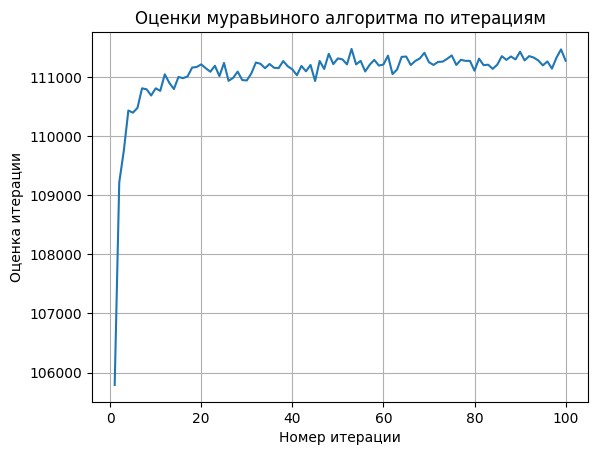

In [24]:
plt.plot(np.arange(1, iterations_count+1), iteration_ratings)
plt.title("Оценки муравьиного алгоритма по итерациям")
plt.xlabel("Номер итерации")
plt.ylabel("Оценка итерации")
plt.grid()
plt.show()

## Метрики

Процент прироста загруженности магазинов по товарам

In [25]:
load_boost_per_store = np.divide(best_solution, maxcap, out=np.full((N, M), np.nan), where= maxcap != 0)

Максимальный процент прироста загруженности

In [26]:
np.nanmax(load_boost_per_store)

np.float64(26.0)

Средний процент прироста загруженности

In [27]:
np.nanmean(load_boost_per_store)

np.float64(0.014087412920553512)

Процент прироста количества товаров по магазинам

In [28]:
stock_boost_per_store = np.divide(best_solution, remains, out=np.full((N, M), np.nan), where= remains != 0)

Максимальный процент прироста количества товаров

In [29]:
np.nanmax(stock_boost_per_store)

np.float64(276.0)

Средний процент прироста количества товаров

In [30]:
np.nanmean(stock_boost_per_store)

np.float64(0.03618689790551078)

## Выгрузка решения

In [31]:
def output_csv(df, filename, with_index=False):
    df_dirpath = Path(r"./solutions")
    df_dirpath.mkdir(parents=True, exist_ok=True)

    df_filepath = df_dirpath / filename

    with df_filepath.open("w") as f:
        df.to_csv(f, sep=";", lineterminator="\n", index=with_index)

In [32]:
df_solution = pd.DataFrame(best_solution, index=items_id, columns=stores_id).stack()
df_full[col_dist] = df_solution.reindex(df_full.index).values
df_full

Объём товара в закрывающемся магазине (V)  \
Код товара Магазин                                              
226249     54                                            10.0   
           56                                            10.0   
           57                                            10.0   
           60                                            10.0   
           61                                            10.0   
...                                                       ...   
239221     88                                             NaN   
           105                                            NaN   
           29                                             NaN   
           27                                             NaN   
           113                                           17.0   

                    Продажи товара в магазине (S)  \
Код товара Магазин                                  
226249     54                            1.379157   
           56                            0.943567   
           57                            0.857143   
           60                            0.406742   
           61                            0.713024   
...                                           ...   
239221     88                                 NaN   
           105                                NaN   
           29                                 NaN   
           27                                 NaN   
           113                           0.302326   

                    Максимальная вместимость товара в магазине (M)  \
Код товара Магазин                                                   
226249     54                                                  8.0   
           56                                                  8.0   
           57                                                  8.0   
           60                                                  8.0   
           61                                                  8.0   
...                                                            ...   
239221     88                                                  NaN   
           105                                                 NaN   
           29                                                  NaN   
           27                                                  NaN   
           113                                                10.0   

                    Остаток товара в магазине (R)  Распределение муравьёв  
Код товара Магазин                                                         
226249     54                                16.0                       0  
           56                                22.0                       0  
           57                                19.0                       0  
           60                                28.0                       0  
           61                                22.0                       0  
...                                           ...                     ...  
239221     88                                 NaN                       0  
           105                                NaN                       0  
           29                                 NaN                       0  
           27                                 NaN                       0  
           113                                5.0                       0  

[525868 rows x 5 columns]

In [33]:
output_csv(df_full.dropna(), "ant_solution.csv", with_index=True)